In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

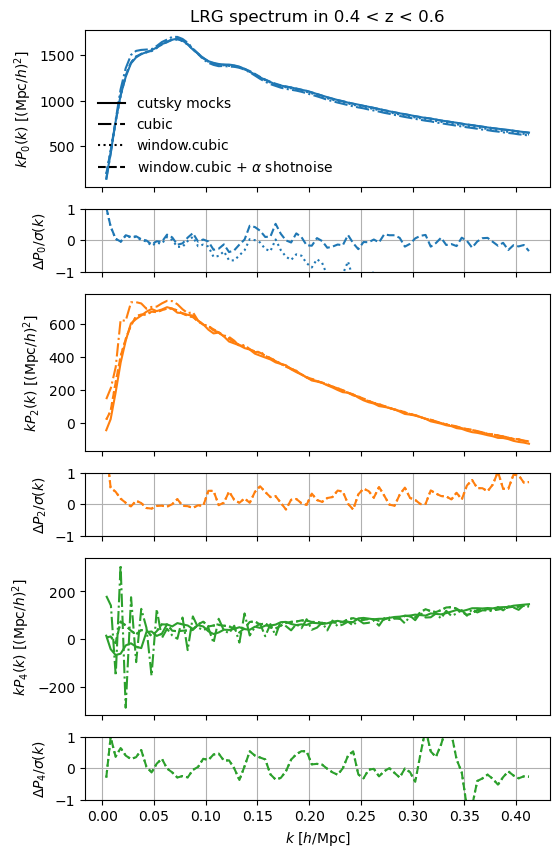

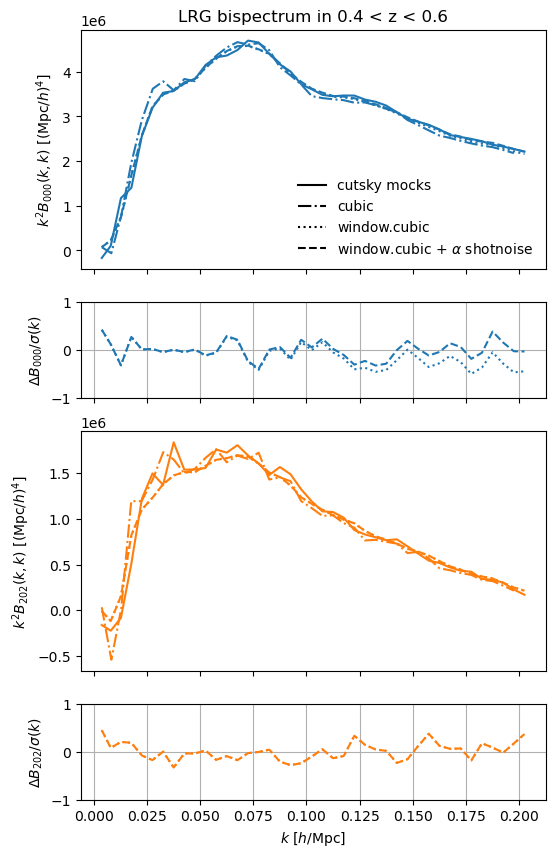

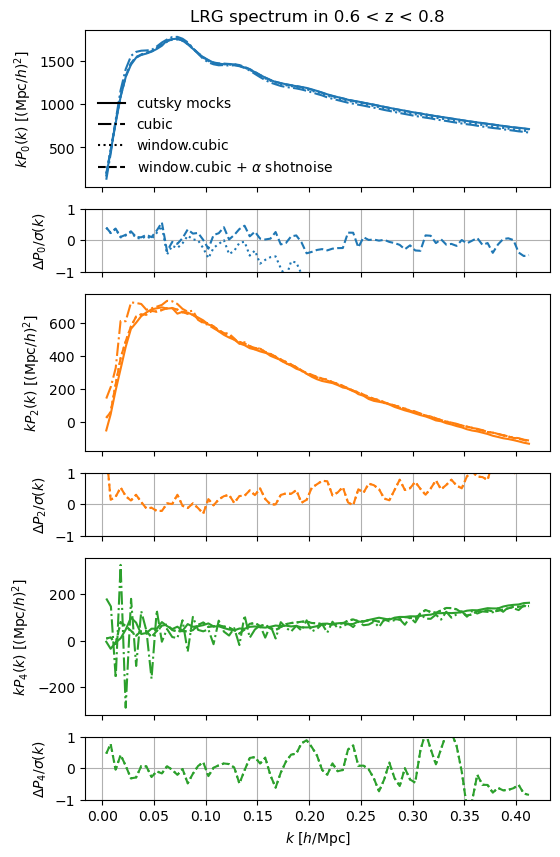

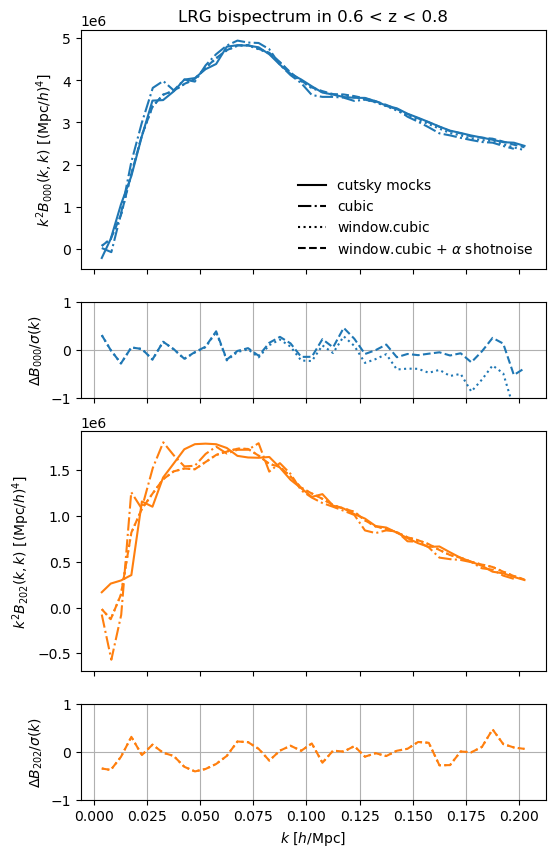

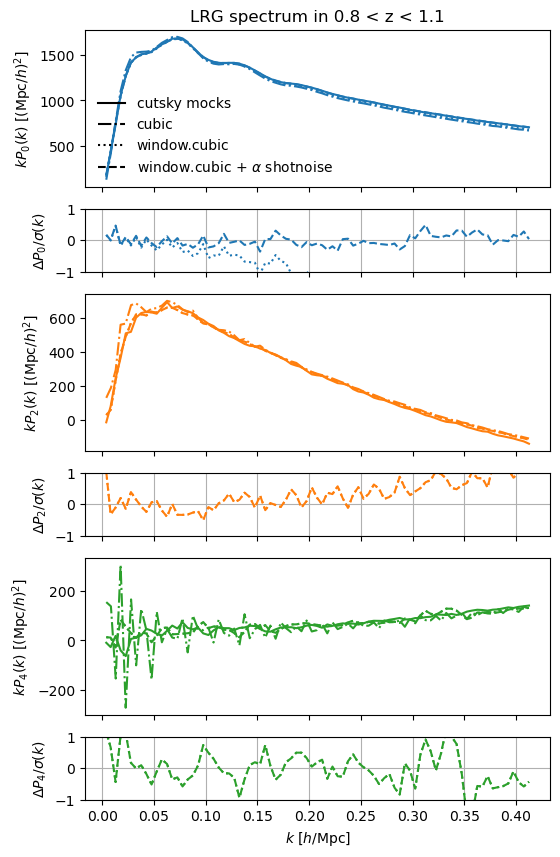

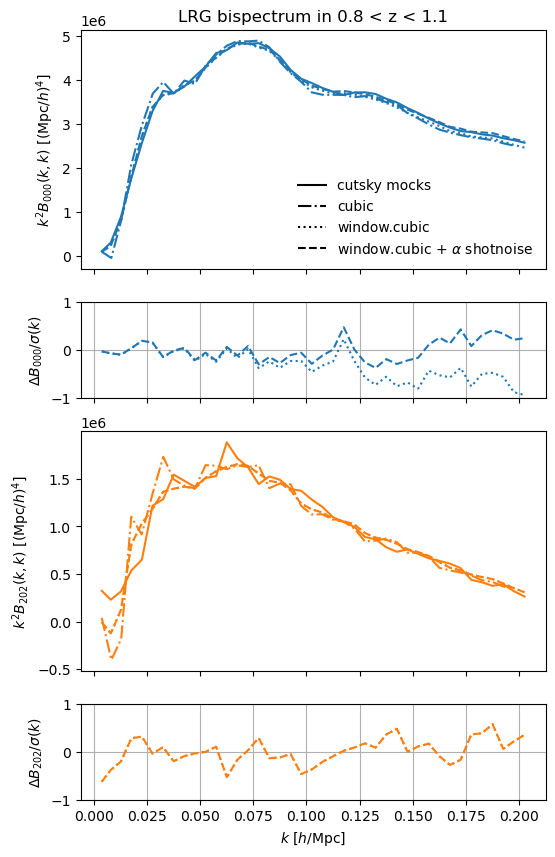

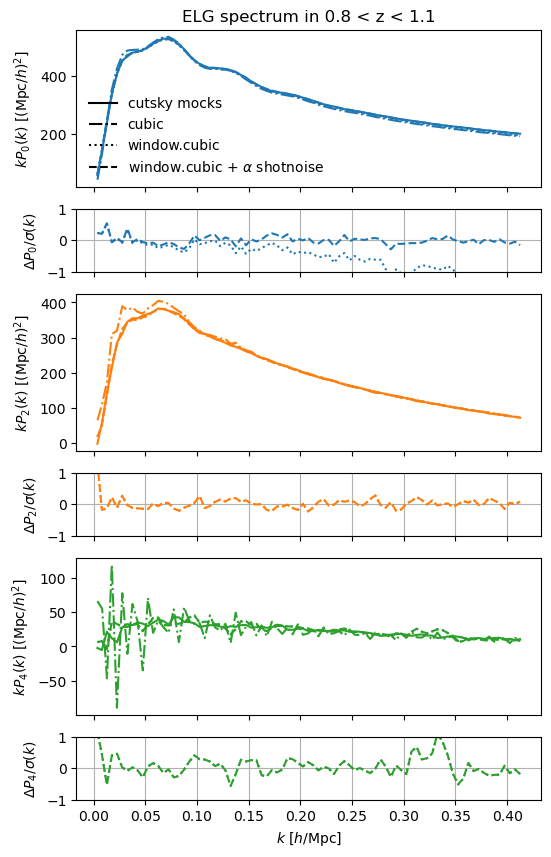

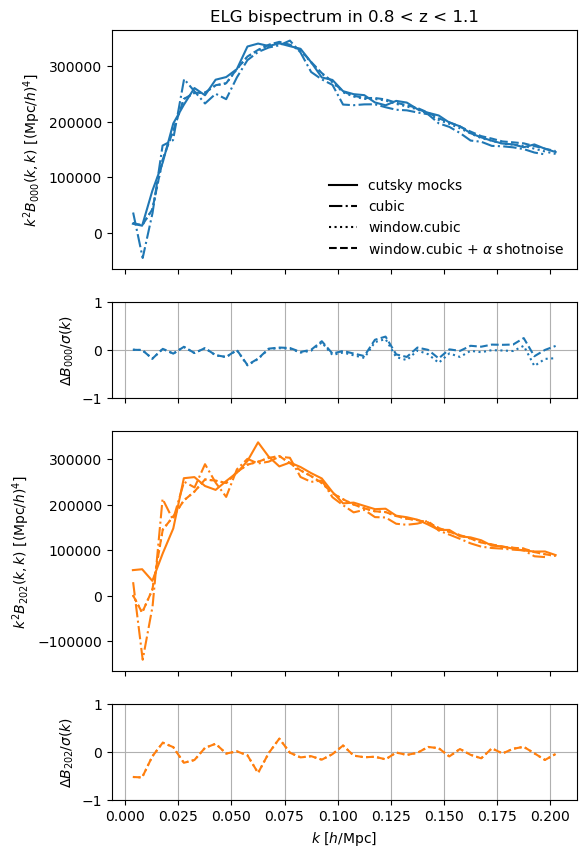

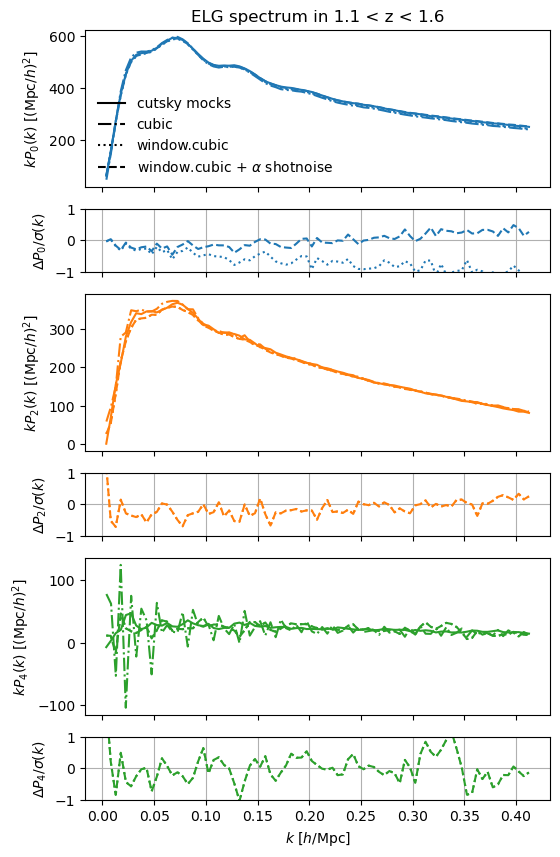

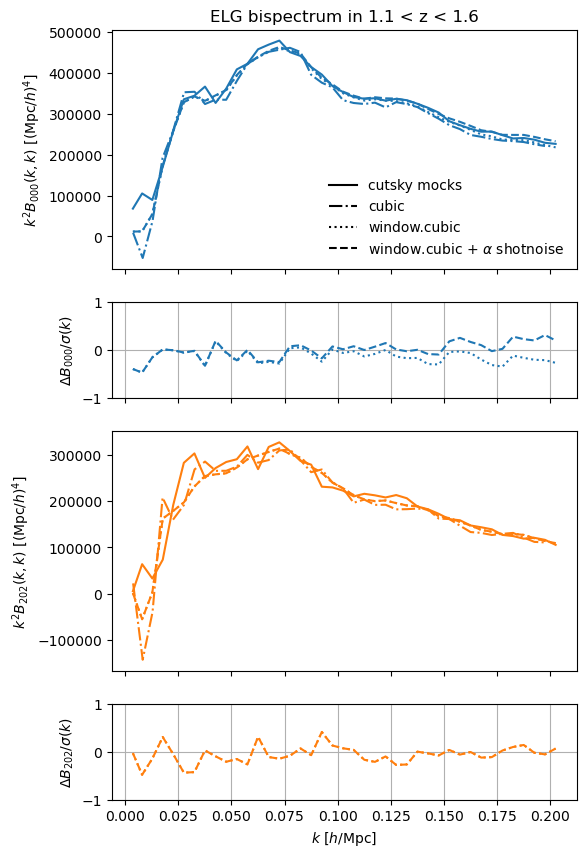

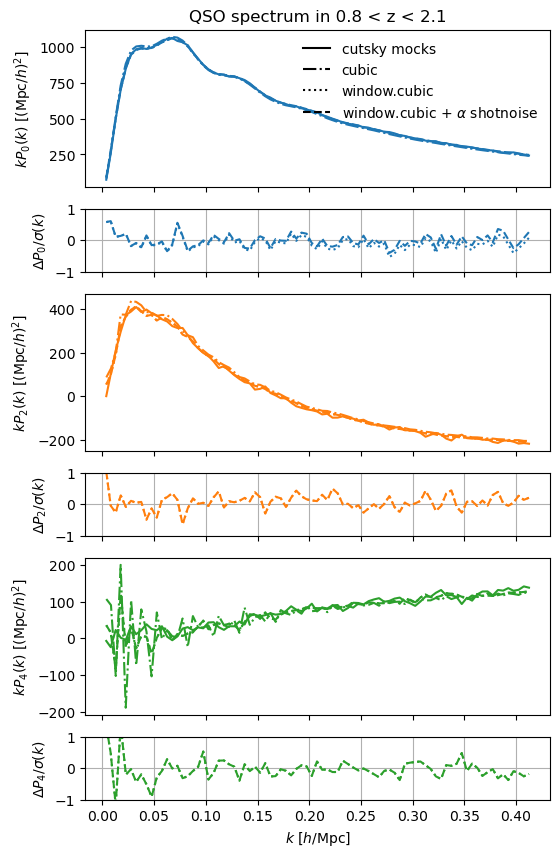

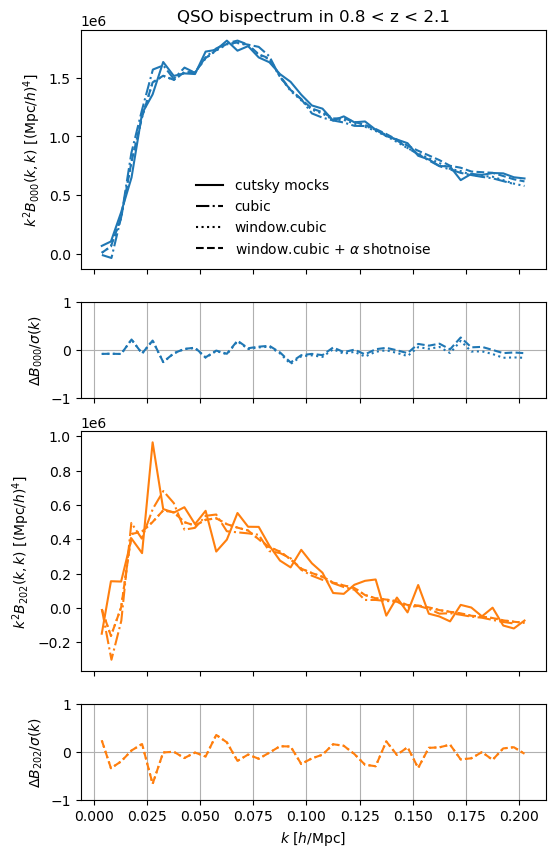

In [2]:
for tracer in ['LRG', 'ELG', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
            nmocks = 25
            region = 'NGC'
            zsnap = box_tools.get_zsnap_from_z(tracer, zrange, version='abacus-hf-v2')
            stracer = tools.get_simple_tracer(tracer)
            stats_dir = tools.base_stats_dir
            hod = {'LRG': 'base_B', 'ELG': 'base_conf_nfwexp', 'QSO': 'base'}[stracer]
            fns = [box_tools.get_box_stats_fn(stats_dir=stats_dir, project='full_shape/box_window_function_validation', kind=kind, version='abacus-hf-v2', tracer=stracer,
                                              zsnap=zsnap, cosmo='000', hod=hod, los='z', basis='sugiyama', imock=imock) for imock in range(nmocks)]
            mocks_box = [types.read(fn) for fn in fns if fn.exists()]
            mean_box = types.mean(mocks_box)
            onthefly = 'complete'
            ftracer = tools.get_full_tracer(tracer, version='abacus-hf-dr2-v2-altmtl')
            fns = [tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=kind, version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra=onthefly, imock=imock) for imock in range(nmocks)]
            mocks_cutsky = [types.read(fn) for fn in fns if fn.exists()]
            mean_cutsky = types.mean(mocks_cutsky).select(k=slice(0, None, 5 if 'mesh2' in kind else 1))

            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version='holi-v3-altmtl', tracer=ftracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.match(mean_cutsky)

            fn = tools.get_stats_fn(stats_dir=stats_dir, project='full_shape/fiber_assignment_systematics', kind=f'window_{kind}', version='abacus-hf-dr2-v2-altmtl', tracer=ftracer,
                                    zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra=onthefly, imock=0)
            window_cutsky = types.read(fn).at.observable.match(mean_cutsky)
            mean_box_interp = []
            for label, pole in window_cutsky.theory.items():
                pole_box = mean_box.get(ells=label['ells'])
                if 'mesh3' in kind:
                    pole_box = pole_box.unravel()
                    from scipy import interpolate
                    mask1, mask2 = [np.any(pole_box.values('nmodes') > 0, axis=axis) for axis in [1, 0]]
                    spline = interpolate.RectBivariateSpline(pole_box.coords('k1')[mask1], pole_box.coords('k2')[mask2], pole_box.value()[np.ix_(mask1, mask2)], kx=1, ky=1, s=0)
                    pole = spline(*pole.coords('k').T, grid=False)
                else:
                    mask = pole_box.values('nmodes') > 0
                    pole = np.interp(pole.coords('k'), pole_box.coords('k')[mask], pole_box.value()[mask])
                mean_box_interp.append(pole)
            mean_box_interp = window_cutsky.theory.clone(value=np.concatenate(mean_box_interp))
            mean_box_conv = window_cutsky.dot(mean_box_interp, return_type=None)
            
            shotnoise = window_cutsky.theory.clone(value=0. * window_cutsky.theory.value()).value(concatenate=False)
            shotnoise[0] += next(iter(mean_cutsky)).values('shotnoise').mean()
            shotnoise = window_cutsky.dot(np.concatenate(shotnoise), return_type='nparray')[None, ...]
            precision = np.diag(1. / cov.std())
            # Solve d\chi^2 / drescale = 0, theory = rescale * shotnoise, data = mean_cutsky - mean_box_conv
            rescale = np.linalg.solve(shotnoise.dot(precision).dot(shotnoise.T), shotnoise.dot(precision).dot(mean_cutsky.value() - mean_box_conv.value()))
            mean_box_conv_shotnoise = mean_box_conv.clone(value=mean_box_conv.value() + rescale.dot(shotnoise))

            nmocks = min(len(mocks_box), len(mocks_cutsky))  # scale error bars
            if 'mesh2' in kind:
                ells = mean_cutsky.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_box.get(ell).select(k=slice(0, None, 5)).select(k=(0., mean_cutsky.get(ell).edges('k').max()))
                    ax.plot(pole.coords('k'), pole.coords('k') * pole.value(), color=color, linestyle='-.')
                    pole = mean_cutsky.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean_box_conv.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole_cutsky = mean_cutsky.get(ell)
                    std = cov.at.observable.get(ell).std()
                    pole = mean_box_conv.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_cutsky.value()) / std, color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_cutsky.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='cutsky mocks')
                ax.plot([], [], color='k', linestyle='-.', label='cubic')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)
                plt.show()

            elif 'mesh3' in kind:
                ells = mean_cutsky.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    pole = mean_box.get(tuple(sorted(ell[:2])) + ell[2:]).select(k=(0., 0.2)).unravel()
                    ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle='-.')
                    #pole = mean_box_interp.get(ells=tuple(sorted(ell[:2])) + ell[2:]).unravel()
                    #ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle='-')
                    pole = mean_cutsky.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    pole = mean_box_conv.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole_cutsky = mean_cutsky.get(ell)
                    std = cov.at.observable.get(ell).std()
                    pole = mean_box_conv.get(ell)
                    ax.plot(k, (pole.value() - pole_cutsky.value()) / std, color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k, (pole.value() - pole_cutsky.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='cutsky mocks')
                ax.plot([], [], color='k', linestyle='-.', label='cubic')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)
                plt.show()